# Model Testing (CPU)

Offline inference on dataset images with wheel output preview.

This notebook loads a trained model on CPU, runs predictions on dataset images,
and shows predicted target points plus the computed left/right wheel values.
No JetBot hardware is needed.

In [17]:
import glob
import math
import os
import random

import numpy as np
import pandas as pd
import PIL.Image
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms

DATASET_NAME = 'dataset_labeled_4_fast'
DATASET_DIR = f'datasets/{DATASET_NAME}'
MODEL_PATH = f'models/{DATASET_NAME}/best_resnet18_224.pth'
DEVICE = torch.device('cpu')

# Controls that affect wheel output
SPEED_GAIN = 0.2
STEERING_GAIN = 0.2
STEERING_BIAS = 0.0
STEERING_DGAIN = 0.0

In [18]:
image_paths = sorted(glob.glob(os.path.join(DATASET_DIR, '*.jpg')))
if not image_paths:
    raise FileNotFoundError(f'No .jpg images found in {DATASET_DIR}')

labels_csv = os.path.join(DATASET_DIR, 'labels.csv')
labels_map = {}
if os.path.exists(labels_csv):
    df_labels = pd.read_csv(labels_csv)
    labels_map = {
        os.path.basename(r['image_path']): (float(r['x_norm']), float(r['y_norm']))
        for _, r in df_labels.iterrows()
    }

print(f'Images: {len(image_paths)}')
print(f'Labels: {len(labels_map)}')

Images: 445
Labels: 445


In [19]:
model = torchvision.models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(512, 2)
state = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state)
model.to(DEVICE)
model.eval()

print('Model loaded on', DEVICE)

Model loaded on cpu


In [20]:

mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

def preprocess_live_demo_cpu(image):
    # dokładnie jak live_demo, tylko bez cuda i half

    if isinstance(image, PIL.Image.Image):
        image = np.array(image)

    image = PIL.Image.fromarray(image)

    tensor = transforms.functional.to_tensor(image)

    tensor.sub_(mean[:, None, None])
    tensor.div_(std[:, None, None])

    return tensor.unsqueeze(0)

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def predict_xy(image):
    tensor = preprocess_live_demo_cpu(image)
    with torch.no_grad():
        xy = model(tensor).detach().cpu().numpy().flatten()
    return xy


def compute_wheel_output(
    xy,
    speed_gain=SPEED_GAIN,
    steering_gain=STEERING_GAIN,
    steering_bias=STEERING_BIAS,
    steering_dgain=STEERING_DGAIN,
    angle_last=0.0,
):
    x = xy[0] - 0.5
    y = 1.0 - xy[1]
    angle = np.arctan2(x, y)

    pid = angle * steering_gain + (angle - angle_last) * steering_dgain
    steering = pid + steering_bias

    # steering = speed_gain * steering_gain * angle + steering_bias
    
    left  = float(np.clip(speed_gain + steering, 0.0, 1.0))
    right = float(np.clip(speed_gain - steering, 0.0, 1.0))
    return {
        'x':       float(xy[0]),
        'y':       float(xy[1]),
        'angle':   float(angle),
        'steering': float(steering),
        'left':    left,
        'right':   right,
    }

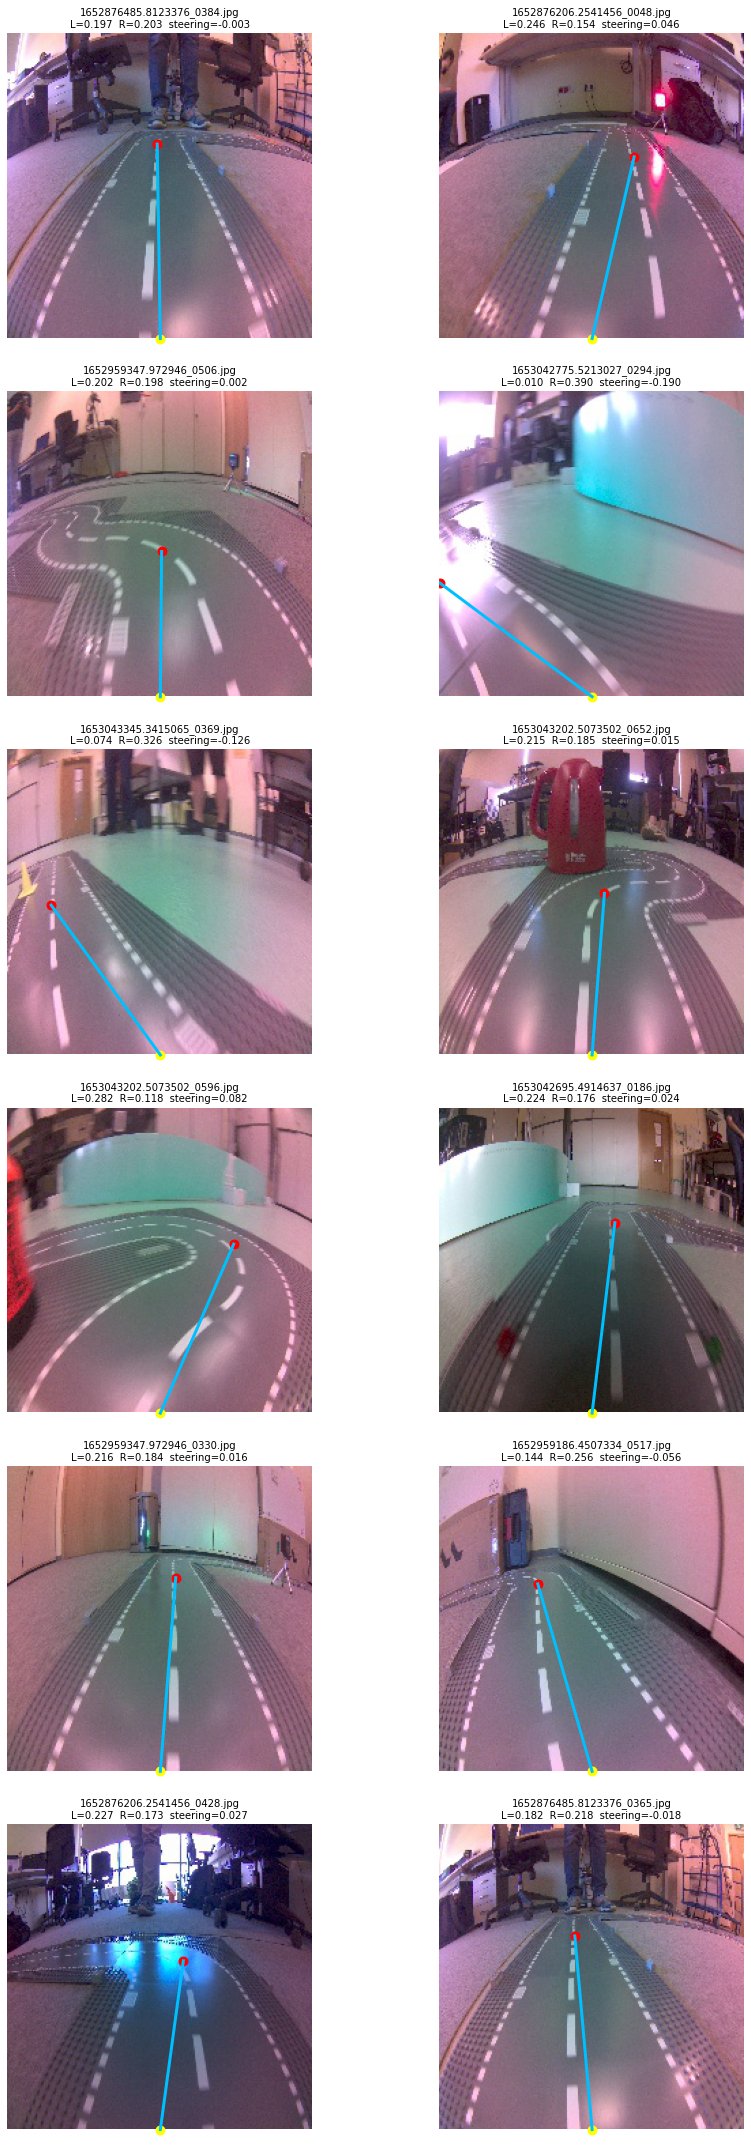

In [21]:
def show_sample_predictions(num_samples=4, seed=423):
    random.seed(seed)
    sample_paths = random.sample(image_paths, min(num_samples, len(image_paths)))

    cols = 2
    rows = math.ceil(len(sample_paths) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, img_path in zip(axes, sample_paths):
        image = PIL.Image.open(img_path).convert('RGB')
        width, height = image.size
        xy = predict_xy(image)
        output = compute_wheel_output(xy)

        pred_x = np.clip(output['x'], 0.0, 1.0) * width
        pred_y = np.clip(output['y'], 0.0, 1.0) * height
        center_x = width / 2
        center_y = height

        ax.imshow(image)
        ax.plot([center_x, pred_x], [center_y, pred_y], color='deepskyblue', linewidth=3)
        ax.scatter([pred_x], [pred_y], c='red', s=80)
        ax.scatter([center_x], [center_y], c='yellow', s=80)
        ax.set_title(
            f"{os.path.basename(img_path)}\n"
            f"L={output['left']:.3f}  R={output['right']:.3f}  steering={output['steering']:.3f}",
            fontsize=10,
        )
        ax.axis('off')

    for ax in axes[len(sample_paths):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


show_sample_predictions(num_samples=12)

In [9]:
import time


def benchmark_inference(num_images=20, repeats=10, seed=123):
    random.seed(seed)
    sample_paths = random.sample(image_paths, min(num_images, len(image_paths)))

    rows = []
    with torch.no_grad():
        for img_path in sample_paths:
            image = PIL.Image.open(img_path).convert('RGB')

            start = time.perf_counter()
            xy = None
            for _ in range(repeats):
                xy = predict_xy(image)

            output = compute_wheel_output(xy)

            elapsed = (time.perf_counter() - start) / repeats
            
            rows.append({
                'image': os.path.basename(img_path),
                'time_ms': elapsed * 1000.0,
                'x': output['x'],
                'y': output['y'],
                'steering': output['steering'],
                'left': output['left'],
                'right': output['right'],
            })

    results = pd.DataFrame(rows).sort_values('time_ms', ascending=False).reset_index(drop=True)
    print(f"Average inference time: {results['time_ms'].mean():.2f} ms")
    print(f"Min inference time: {results['time_ms'].min():.2f} ms")
    print(f"Max inference time: {results['time_ms'].max():.2f} ms")
    return results


benchmark_results = benchmark_inference(num_images=10, repeats=20)
benchmark_results

NameError: name 'random' is not defined

In [ ]:
import numpy as np
import random
import PIL.Image

random.seed(42)
sample_paths = random.sample(image_paths, min(8, len(image_paths)))

print(f"{'obraz':<30} {'x':>6} {'y':>6} {'angle':>8} {'steering':>10} {'left':>7} {'right':>7}")
print("-" * 80)

for img_path in sample_paths:
    image = PIL.Image.open(img_path).convert('RGB')
    xy = predict_xy(image)
    
    x_raw = xy[0]
    y_raw = xy[1]
    
    x = x_raw - 0.5
    y = (1.0 - y_raw)        # zamiast 0.5 - y_raw — y zawsze dodatnie [0..1]
    angle = np.arctan2(x, y)
    pid = angle * STEERING_GAIN + 0.0  # dgain=0
    steering = pid + STEERING_BIAS
    left  = float(np.clip(SPEED_GAIN + steering, 0.0, 1.0))
    right = float(np.clip(SPEED_GAIN - steering, 0.0, 1.0))
    
    print(f"{img_path[-28:]:<30} {x_raw:>6.3f} {y_raw:>6.3f} {angle:>8.3f} {steering:>10.3f} {left:>7.3f} {right:>7.3f}")

obraz                               x      y    angle   steering    left   right
--------------------------------------------------------------------------------
\1653043345.3415065_0076.jpg    0.148  0.618   -1.894     -0.379   0.000   0.579
2\1652876013.741493_0230.jpg    0.965  0.628    1.839      0.368   0.568   0.000
\1652875901.3107166_0041.jpg    0.564  0.410    0.613      0.123   0.323   0.077
\1653043428.8546412_0323.jpg    0.554  0.577    2.536      0.507   0.707   0.000
\1652876485.8123376_0303.jpg    0.559  0.547    2.248      0.450   0.650   0.000
\1652876206.2541456_0875.jpg    0.531  0.312    0.162      0.032   0.232   0.168
\1652876206.2541456_0585.jpg    0.327  0.374   -0.940     -0.188   0.012   0.388
2\1652876013.741493_0436.jpg    0.627  0.371    0.781      0.156   0.356   0.044


# ROBOT TESTING

In [ ]:
import torch
import torchvision
import numpy as np
import PIL.Image
from jetbot import Camera, Robot, bgr8_to_jpeg
import torchvision.transforms as transforms
import ipywidgets
import traitlets
from IPython.display import display

# ── ścieżka do modelu ────────────────────────────────────────────────────────
MODEL_PATH = './models/model_to_import.pth'
# ────────────────────────────────────────────────────────────────────────────

# model
model = torchvision.models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(512, 2)
model.load_state_dict(torch.load(MODEL_PATH))
device = torch.device('cpu')
model = model.to(device).eval()
print('Model załadowany na', device)

# preprocessing (identyczny z live_demo)
mean_cpu = torch.tensor([0.485, 0.456, 0.406])
std_cpu  = torch.tensor([0.229, 0.224, 0.225])

def preprocess_cpu(image):
    # dokładnie jak live_demo, tylko bez cuda i half

    if isinstance(image, PIL.Image.Image):
        image = np.array(image)

    image = PIL.Image.fromarray(image)

    tensor = transforms.functional.to_tensor(image)

    tensor.sub_(mean_cpu[:, None, None])
    tensor.div_(std_cpu[:, None, None])

    return tensor.unsqueeze(0)

def predict_xy_cpu(image):
    tensor = preprocess_cpu(image)
    with torch.no_grad():
        xy = model(tensor).detach().cpu().numpy().flatten()
    return xy

# mean_gpu = torch.Tensor([0.485, 0.456, 0.406]).cuda().half()
# std_gpu  = torch.Tensor([0.229, 0.224, 0.225]).cuda().half()

# def preprocess_gpu(image):
#     if isinstance(image, PIL.Image.Image):
#         image = np.array(image)
#     image = PIL.Image.fromarray(image)
#     tensor = transforms.functional.to_tensor(image).to(device).half()
#     tensor.sub_(mean_gpu[:, None, None]).div_(std_gpu[:, None, None])
#     return tensor.unsqueeze(0)

# def predict_xy_gpu(image):
#     tensor = preprocess_gpu(image)
#     with torch.no_grad():
#         xy = model(tensor).detach().float().cpu().numpy().flatten()
#     return xy

def compute_wheel_output(
    xy,
    speed_gain=0.2,
    steering_gain=0.2,
    steering_bias=0.0,
    steering_dgain=0.0,
    angle_last=0.0,
):
    x = xy[0] - 0.5
    y = 1.0 - xy[1]
    angle = np.arctan2(x, y)

    pid = angle * steering_gain + (angle - angle_last) * steering_dgain
    steering = pid + steering_bias

#     steering = speed_gain * steering_gain * angle + steering_bias
    
    left  = float(np.clip(speed_gain + steering, 0.0, 1.0))
    right = float(np.clip(speed_gain - steering, 0.0, 1.0))
    return {
        'x':       float(xy[0]),
        'y':       float(xy[1]),
        'angle':   float(angle),
        'steering': float(steering),
        'left':    left,
        'right':   right,
    }


Model załadowany na cpu
Kamera i robot gotowe


In [ ]:
# kamera
camera = Camera()
image_widget = ipywidgets.Image()
traitlets.dlink((camera, 'value'), (image_widget, 'value'), transform=bgr8_to_jpeg)

# robot
robot = Robot()

print('Kamera i robot gotowe')

import time
import numpy as np
import pandas as pd

# ── parametry (te same co w live_demo) ──────────────────────────────────────
SPEED_GAIN     = 1.0
STEERING_GAIN  = 0.5
STEERING_DGAIN = 0.0
STEERING_BIAS  = -0.25
N_FRAMES       = 50   # ile klatek zmierzyć
# ────────────────────────────────────────────────────────────────────────────

angle_last = 0.0
rows = []
timestamps = []
frames = []

for i in range(N_FRAMES):

    timestamps.append(time.perf_counter())
    
    # 1. odczyt klatki z kamery
    t0 = time.perf_counter()
    frame = camera.value
    t1 = time.perf_counter()

    t2 = time.perf_counter()

    # 3. inferencja modelu
    xy = predict_xy_cpu(frame)
    t3 = time.perf_counter()

    # 4. sterowanie (execute)
    x_raw, y_raw = float(xy[0]), float(xy[1])
    output = compute_wheel_output([x_raw, y_raw], angle_last=angle_last)
    angle_last = output['angle']
    left  = output['left']
    right = output['right']
    t4 = time.perf_counter()

    # 5. zapis na silniki
    robot.right_motor.value = right
    robot.left_motor.value  = left
    
    if (output['steering'] > 0.1):
        time.sleep(0.2)
    else:
        time.sleep(0.5)
    
    robot.right_motor.value = 0.0
    robot.left_motor.value  = 0.0
    
    t5 = time.perf_counter()

    frames.append(frame.copy())
    rows.append({
        'klatka':        i,
        'kamera_ms':     (t1 - t0) * 1000,
        'preprocess_ms': (t2 - t1) * 1000,
        'model_ms':      (t3 - t2) * 1000,
        'execute_ms':    (t4 - t3) * 1000,
        'silniki_ms':    (t5 - t4) * 1000,
        'total_ms':      (t5 - t0) * 1000,
        'x':             x_raw,
        'y':             y_raw,
        'angle':         output['angle'],
        'steering':      output['steering'],
        'left':          left,
        'right':         right,
    })

# zatrzymaj robota po teście
robot.stop()
camera.stop()

df = pd.DataFrame(rows)

print("=== ŚREDNIE CZASY ===")
for col in ['kamera_ms', 'preprocess_ms', 'model_ms', 'execute_ms', 'silniki_ms', 'total_ms']:
    print(f"  {col:<16} avg={df[col].mean():6.2f}ms   max={df[col].max():6.2f}ms")

print(f"\n=== FPS (total) ===  avg={1000/df['total_ms'].mean():.1f}  min={1000/df['total_ms'].max():.1f}")

print("\n=== PREDYKCJE + STEROWANIE ===")
print(df[['klatka','x','y','angle','steering','left','right']].to_string(index=False))

print("\n=== ODSTĘPY MIĘDZY KLATKAMI ===")
gaps = [(timestamps[i+1] - timestamps[i]) * 1000 for i in range(len(timestamps) - 1)]
t_start = timestamps[0]
df_gaps = pd.DataFrame({
    'klatka':      range(1, len(gaps) + 1),
    'czas_od_startu_ms': [(timestamps[i] - t_start) * 1000 for i in range(1, len(timestamps))],
    'gap_ms':      gaps,
    'fps_instant': [1000 / g for g in gaps],
})

print(f"  avg gap: {np.mean(gaps):.2f}ms  |  max gap: {np.max(gaps):.2f}ms  |  min gap: {np.min(gaps):.2f}ms")
print(f"  avg FPS: {1000/np.mean(gaps):.1f}  |  min FPS: {1000/np.max(gaps):.1f}")
print()
print(df_gaps.to_string(index=False))

=== ŚREDNIE CZASY ===
  kamera_ms        avg=  0.02ms   max=  0.04ms
  preprocess_ms    avg=  0.00ms   max=  0.00ms
  model_ms         avg=614.22ms   max=738.98ms
  execute_ms       avg=  0.41ms   max=  0.51ms
  silniki_ms       avg=475.52ms   max=640.17ms
  total_ms         avg=1090.18ms   max=1374.24ms

=== FPS (total) ===  avg=0.9  min=0.7

=== PREDYKCJE + STEROWANIE ===
klatka         x         y     angle  steering      left     right
     0  0.532514  0.269588  0.044485  0.008897  0.208897  0.191103
     1  0.571629  0.315336  0.104240  0.020848  0.220848  0.179152
     2  0.526817  0.361155  0.041953  0.008391  0.208391  0.191609
     3  0.561994  0.464472  0.115250  0.023050  0.223050  0.176950
     4  0.851679  0.531446  0.643862  0.128772  0.328772  0.071228
     5  0.884403  0.403529  0.572472  0.114494  0.314494  0.085506
     6  0.823137  0.265624  0.414520  0.082904  0.282904  0.117096
     7  0.581481  0.249603  0.108160  0.021632  0.221632  0.178368
     8  0.300211  0.

### ZDJECIA TUTAJ POWINNY BYC Z PREDYCKAJMI

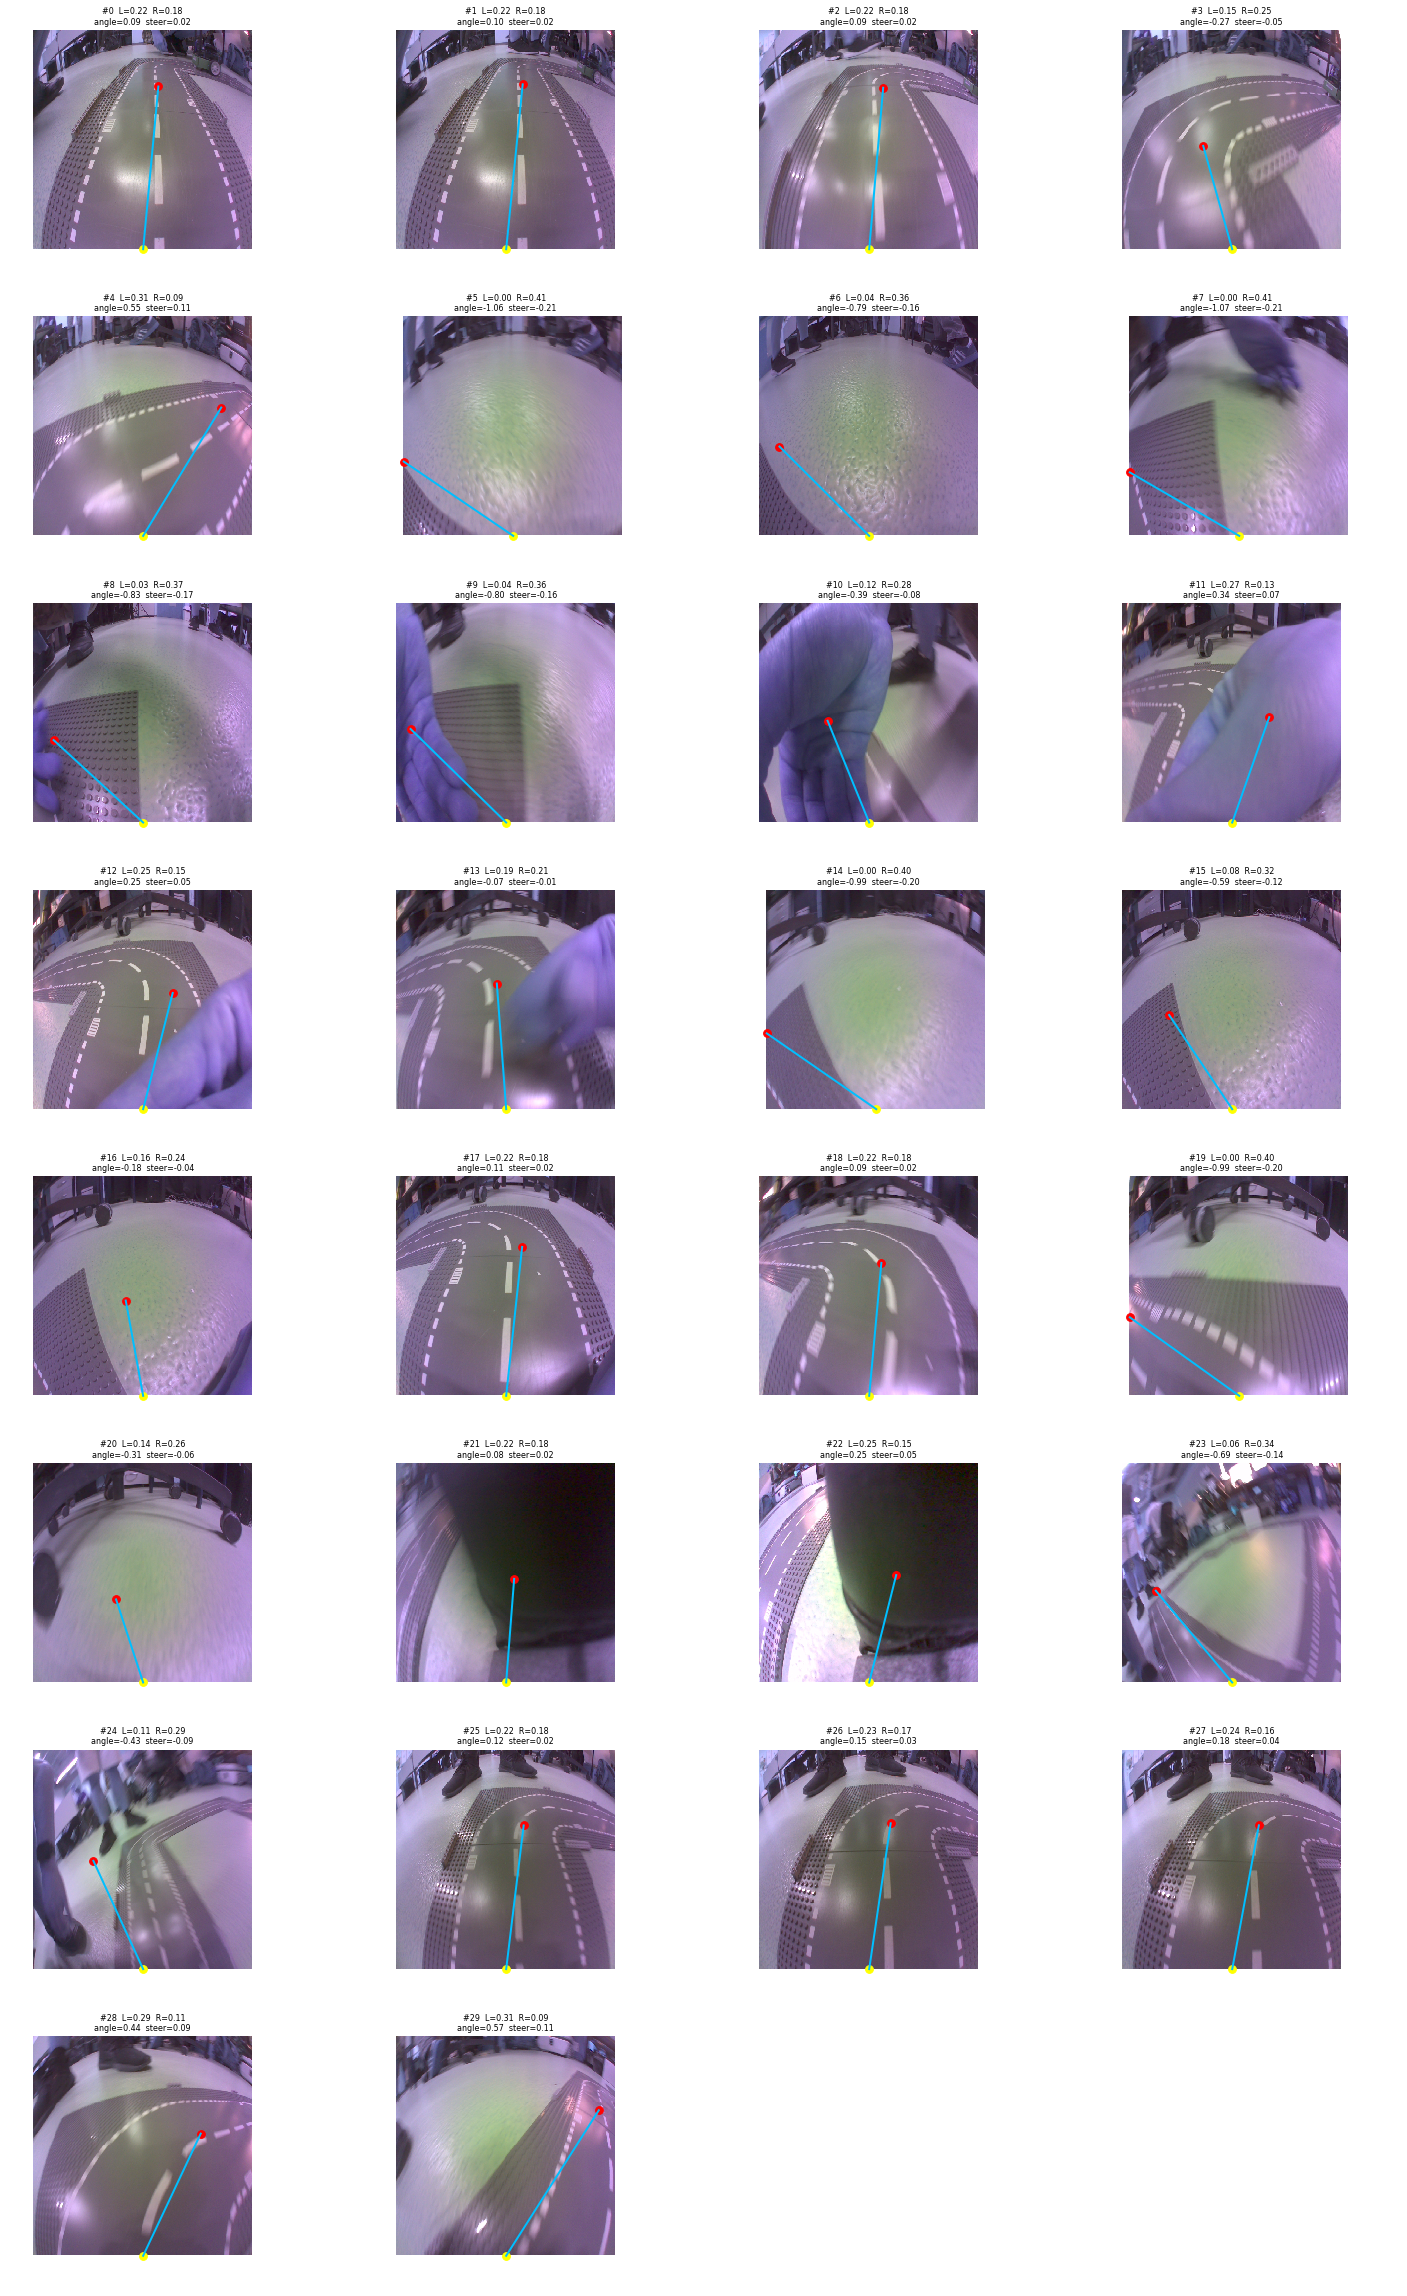

In [10]:
import matplotlib.pyplot as plt
import math
%matplotlib inline

cols = 4
rows = math.ceil(N_FRAMES / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, row in df.iterrows():
    ax = axes[i]
    
    # zdekoduj klatkę z kamery — potrzebujemy zapisanych klatek
    frame = frames[i]
    image = PIL.Image.fromarray(frame)
    width, height = image.size
    
    pred_x = np.clip(row['x'], 0.0, 1.0) * width
    pred_y = np.clip(row['y'], 0.0, 1.0) * height
    center_x = width / 2
    center_y = height
    
    ax.imshow(image)
    ax.plot([center_x, pred_x], [center_y, pred_y], color='deepskyblue', linewidth=2)
    ax.scatter([pred_x], [pred_y], c='red', s=60)
    ax.scatter([center_x], [center_y], c='yellow', s=60)
    ax.set_title(
        f"#{i}  L={row['left']:.2f}  R={row['right']:.2f}\n"
        f"angle={row['angle']:.2f}  steer={row['steering']:.2f}",
        fontsize=8
    )
    ax.axis('off')

for ax in axes[N_FRAMES:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [18]:
robot.left_motor.value  = 0.2
robot.right_motor.value = 0.2

In [19]:
robot.stop()

In [31]:
torch.cuda.is_available()

True

In [ ]:
0.129055  0.270945